In [1]:
import pandas as pd

In [2]:
pd.set_option('display.max_rows', 500)

In [3]:
def parse_maf_to_dataframe(file_path):
    # Список для хранения подходящих строк
    data = []
    
    # Открываем файл на чтение
    with open(file_path, 'r') as file:
        for line in file:
            # Убираем лишние пробелы в начале и конце строки
            stripped_line = line.strip()
            
            # Проверяем, начинается ли строка с 's' и не пустая ли она
            if stripped_line.startswith('s'):
                # Разбиваем строку по пробелам
                parts = stripped_line.split()
                
                # Проверяем, что строка имеет правильный формат (минимум 6 частей)
                if len(parts) >= 6:
                    # Извлекаем нужные значения
                    row = {
                        'name': parts[1],
                        'start': int(parts[2]),
                        'alnSize': int(parts[3]),
                        'strand': parts[4],
                        'seqSize': int(parts[5])
                    }
                    data.append(row)
    
    # Создаем DataFrame
    df = pd.DataFrame(data)
    return df

In [18]:
file_path = '/mnt/SSD4TB/PROJECTS/kozyreva_works/110425_Vch_work/alignments/ref_N16961/alignment/target___M1526.o2o_aln.maf'  # Укажите путь к вашему файлу
result_df = parse_maf_to_dataframe(file_path)

In [19]:
result_df.head()

,name,start,alnSize,strand,seqSize
0,NZ_LT906614.1,0,7411,+,2961182
1,M1526_chr1,2905038,7411,+,2912449
2,NZ_LT906614.1,7411,138078,+,2961182
3,M1526_chr1,0,138039,+,2912449
4,NZ_LT906614.1,147192,3727,+,2961182


In [20]:
result_df['name'].unique()

array(['NZ_LT906614.1', 'M1526_chr1', 'NZ_LT906615.1', 'M1526_chr2'],
      dtype=object)

In [21]:
ref_df = result_df[(result_df['name']=='NZ_LT906614.1') | (result_df['name']=='NZ_LT906615.1')]
q_df = result_df[(result_df['name']=='M1526_chr1') | (result_df['name']=='M1526_chr2')]

In [22]:
ref_df.sort_values('start')

,name,start,alnSize,strand,seqSize
0,NZ_LT906614.1,0,7411,+,2961182
244,NZ_LT906615.1,0,3656,+,1072319
246,NZ_LT906615.1,3975,4028,+,1072319
2,NZ_LT906614.1,7411,138078,+,2961182
248,NZ_LT906615.1,8088,19103,+,1072319
250,NZ_LT906615.1,27237,13511,+,1072319
236,NZ_LT906614.1,33487,21650,-,2961182
252,NZ_LT906615.1,40810,186,+,1072319
254,NZ_LT906615.1,41069,2984,+,1072319
256,NZ_LT906615.1,44053,10864,+,1072319


In [23]:
q_df.sort_values('start')

,name,start,alnSize,strand,seqSize
263,M1526_chr2,0,982,+,1191583
3,M1526_chr1,0,138039,+,2912449
265,M1526_chr2,2291,1521,+,1191583
267,M1526_chr2,5887,3778,+,1191583
269,M1526_chr2,10233,3842,+,1191583
271,M1526_chr2,14095,56718,+,1191583
273,M1526_chr2,78930,4614,+,1191583
275,M1526_chr2,83643,678,+,1191583
277,M1526_chr2,84473,13628,+,1191583
279,M1526_chr2,98173,15544,+,1191583


In [24]:
result_df['group_id'] = 'group' + (result_df.index // 2 + 1).astype(str)

In [25]:
new_df = (
    result_df.groupby('group_id')
    .filter(lambda group: 
        # Проверяем первую строку в группе: name начинается с 'NZ' и strand == '-'
        (group.iloc[0]['name'].startswith('NZ')) & 
        (group.iloc[0]['strand'] == '-')
    )
)

In [26]:
new_df

,name,start,alnSize,strand,seqSize,group_id
6,NZ_LT906614.1,2785985,19121,-,2961182,group4
7,M1526_chr1,2852990,19120,+,2912449,group4
8,NZ_LT906614.1,2764749,6964,-,2961182,group5
9,M1526_chr1,2846021,6966,+,2912449,group5
10,NZ_LT906614.1,2728609,36139,-,2961182,group6
11,M1526_chr1,2809862,36072,+,2912449,group6
12,NZ_LT906614.1,2721850,5564,-,2961182,group7
13,M1526_chr1,2801112,5564,+,2912449,group7
14,NZ_LT906614.1,2720285,418,-,2961182,group8
15,M1526_chr1,2800565,418,+,2912449,group8


In [27]:
new_df['sort_key'] = (
    new_df.groupby('group_id')['start']
    .transform(lambda x: x.iloc[1] if x.iloc[1] is not None else float('inf'))
)

# Сортируем по sort_key (по возрастанию)
new_df_sorted = new_df.sort_values('sort_key')

# Удаляем временный столбец (если не нужен)
new_df_sorted = new_df_sorted.drop(columns=['sort_key'])

In [63]:
new_df_sorted

,name,start,alnSize,strand,seqSize,group_id
237,M1526_chr1,154731,21641,+,2912449,group119
236,NZ_LT906614.1,33487,21650,-,2961182,group119
235,M1526_chr1,176481,16593,+,2912449,group118
234,NZ_LT906614.1,55243,16590,-,2961182,group118
233,M1526_chr1,194289,197752,+,2912449,group117
...,...,...,...,...,...,...
10,NZ_LT906614.1,2728609,36139,-,2961182,group6
9,M1526_chr1,2846021,6966,+,2912449,group5
8,NZ_LT906614.1,2764749,6964,-,2961182,group5
7,M1526_chr1,2852990,19120,+,2912449,group4


In [75]:
new_df_sorted[(new_df_sorted['name']=='M1526_chr1') & (new_df_sorted['alnSize']>1000)].head(150)

,name,start,alnSize,strand,seqSize,group_id
237,M1526_chr1,154731,21641,+,2912449,group119
235,M1526_chr1,176481,16593,+,2912449,group118
233,M1526_chr1,194289,197752,+,2912449,group117
231,M1526_chr1,393480,9881,+,2912449,group116
229,M1526_chr1,405527,9561,+,2912449,group115
227,M1526_chr1,415111,71466,+,2912449,group114
225,M1526_chr1,486924,2152,+,2912449,group113
223,M1526_chr1,489148,41631,+,2912449,group112
221,M1526_chr1,534184,90605,+,2912449,group111
217,M1526_chr1,626795,182997,+,2912449,group109


In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# Фильтрация датафрейма
new2_df = new_df_sorted[(new_df_sorted['name'] == 'M1526_chr1') & (new_df_sorted['alnSize'] > 1000)].copy()

# Сортировка по 'start' (если ещё не отсортировано)
new2_df.sort_values('start', inplace=True)

# Вычисление расстояний между соседними значениями 'start'
new2_df['distance_to_previous'] = new2_df['start'].diff().abs()
new2_df = new2_df[new2_df['distance_to_previous'].notna()]

In [87]:
print(new2_df.shape)
new2_df

(77, 7)


,name,start,alnSize,strand,seqSize,group_id,distance_to_previous
235,M1526_chr1,176481,16593,+,2912449,group118,21750.0
233,M1526_chr1,194289,197752,+,2912449,group117,17808.0
231,M1526_chr1,393480,9881,+,2912449,group116,199191.0
229,M1526_chr1,405527,9561,+,2912449,group115,12047.0
227,M1526_chr1,415111,71466,+,2912449,group114,9584.0
225,M1526_chr1,486924,2152,+,2912449,group113,71813.0
223,M1526_chr1,489148,41631,+,2912449,group112,2224.0
221,M1526_chr1,534184,90605,+,2912449,group111,45036.0
217,M1526_chr1,626795,182997,+,2912449,group109,92611.0
215,M1526_chr1,809934,79118,+,2912449,group108,183139.0


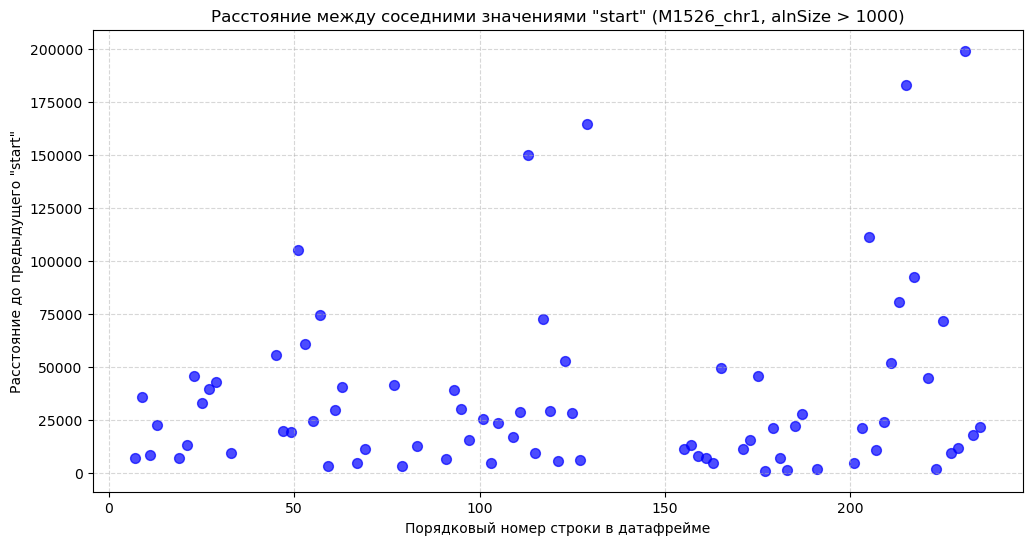

In [81]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=new2_df.index,              # Порядковый номер строки (ось X)
    y=new2_df['distance_to_previous'],  # Расстояние до предыдущего 'start' (ось Y)
    alpha=0.7,                    # Прозрачность точек
    color='blue',
    s=50                          # Размер точек
)

# Настройки графика
plt.title('Расстояние между соседними значениями "start" (M1526_chr1, alnSize > 1000)')
plt.xlabel('Порядковый номер строки в датафрейме')
plt.ylabel('Расстояние до предыдущего "start"')
plt.grid(True, linestyle='--', alpha=0.5)

# Показать график
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [82]:
mean_dist = new2_df['distance_to_previous'].mean()
std_dist = new2_df['distance_to_previous'].std()

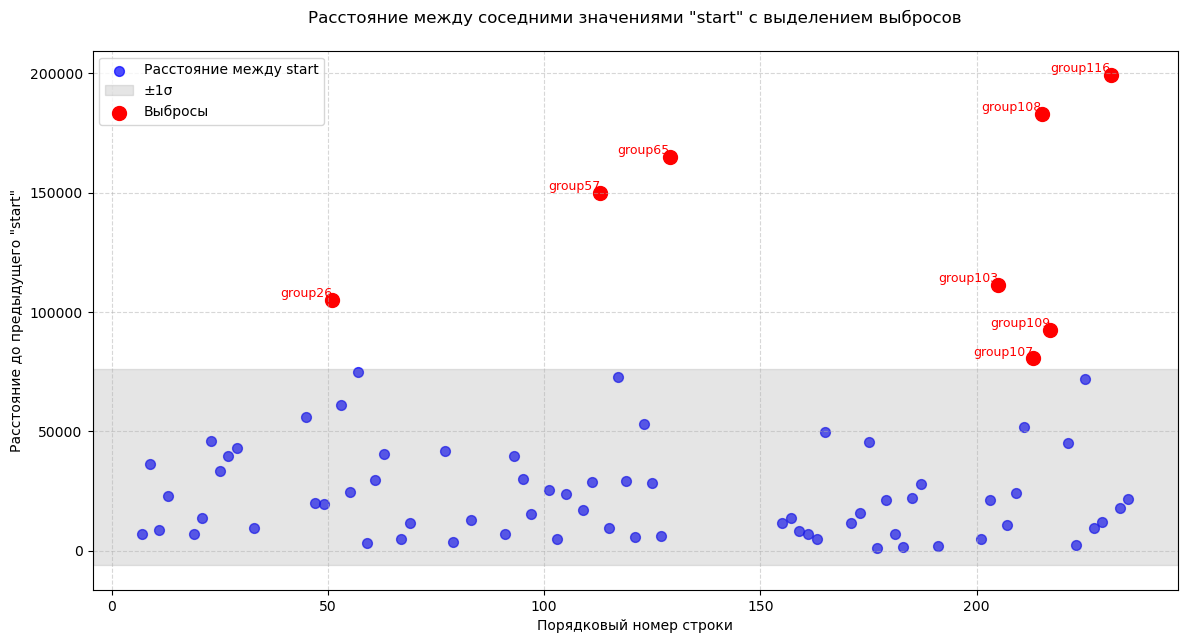

In [84]:
# Настройка основнго графика
plt.figure(figsize=(14, 7))
plt.scatter(
    x=new2_df.index,
    y=new2_df['distance_to_previous'],
    alpha=0.7,
    color='blue',
    s=50,
    label='Расстояние между start'
)

# Добавление области ±σ (полупрозрачная)
plt.axhspan(mean_dist - std_dist, mean_dist + std_dist, color='gray', alpha=0.2, label='±1σ')

# Выделение выбросов (точки за пределами ±σ)
outliers = new2_df[(new2_df['distance_to_previous'] < mean_dist - std_dist) | 
                   (new2_df['distance_to_previous'] > mean_dist + std_dist)]
plt.scatter(
    x=outliers.index,
    y=outliers['distance_to_previous'],
    color='red',
    s=100,
    label='Выбросы'
)

# Подписи для выбросов (group_id)
for idx, row in outliers.iterrows():
    plt.text(
        x=idx,
        y=row['distance_to_previous'],
        s=row['group_id'],
        fontsize=9,
        ha='right',
        va='bottom',
        color='red'
    )

# Настройки оформления
plt.title('Расстояние между соседними значениями "start" с выделением выбросов', pad=20)
plt.xlabel('Порядковый номер строки')
plt.ylabel('Расстояние до предыдущего "start"')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [85]:
# Сохранение списка group_id выбросов
outlier_groups = outliers['group_id'].tolist()
print("Выбросы (group_id):", outlier_groups)

Выбросы (group_id): ['group116', 'group109', 'group108', 'group107', 'group103', 'group65', 'group57', 'group26']


In [88]:
outlier_data = new2_df[new2_df['group_id'].isin(outlier_groups)]
print(outlier_data[['group_id', 'name', 'start', 'distance_to_previous']])

     group_id        name    start  distance_to_previous
231  group116  M1526_chr1   393480              199191.0
217  group109  M1526_chr1   626795               92611.0
215  group108  M1526_chr1   809934              183139.0
213  group107  M1526_chr1   890490               80556.0
205  group103  M1526_chr1  1088658              111378.0
129   group65  M1526_chr1  1530496              164868.0
113   group57  M1526_chr1  1885079              149958.0
51    group26  M1526_chr1  2490889              105129.0


In [89]:
outlier_data = new2_df[new2_df['group_id'].isin(outlier_groups)]
outlier_data

,name,start,alnSize,strand,seqSize,group_id,distance_to_previous
231,M1526_chr1,393480,9881,+,2912449,group116,199191.0
217,M1526_chr1,626795,182997,+,2912449,group109,92611.0
215,M1526_chr1,809934,79118,+,2912449,group108,183139.0
213,M1526_chr1,890490,51200,+,2912449,group107,80556.0
205,M1526_chr1,1088658,21201,+,2912449,group103,111378.0
129,M1526_chr1,1530496,6177,+,2912449,group65,164868.0
113,M1526_chr1,1885079,19093,+,2912449,group57,149958.0
51,M1526_chr1,2490889,19428,+,2912449,group26,105129.0


In [42]:
insertions = df[df['start_q']==df['end_q']] #ins в сборке, то есть в референсе нет ничего, а в сборке есть буквы